In [4]:
import pandas as pd
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr, spearmanr

print(
    "scp cbsu:/home2/ayh8/clipnet_k562/data/mpra/k562_allelic_mpra_snps.csv.gz ~/github/clipnet_k562/siraj_mpra"
)

scp cbsu:/home2/ayh8/clipnet_k562/data/mpra/k562_allelic_mpra_snps.csv.gz ~/github/clipnet_k562/siraj_mpra


In [6]:
data = pd.read_csv("~/github/clipnet_k562/siraj_mpra/k562_allelic_mpra_snps.csv.gz")

In [8]:
data["pred"] = np.log2(data["ref"] / data["alt"])
data["pred_p"] = np.log2(data["ref_p"] / data["alt_p"])
data = data[np.isfinite(data["pred"])]
data.dropna(inplace=True)

pearsons = [
    pearsonr(data[data["fold"] == fold]["expt"], data[data["fold"] == fold]["pred"])[0]
    for fold in range(10)
]
spearmans = [
    spearmanr(data[data["fold"] == fold]["expt"], data[data["fold"] == fold]["pred"])[0]
    for fold in range(10)
]

/Users/adamhe/miniforge3/envs/plt/lib/python3.12/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<Axes: xlabel='expt', ylabel='pred'>

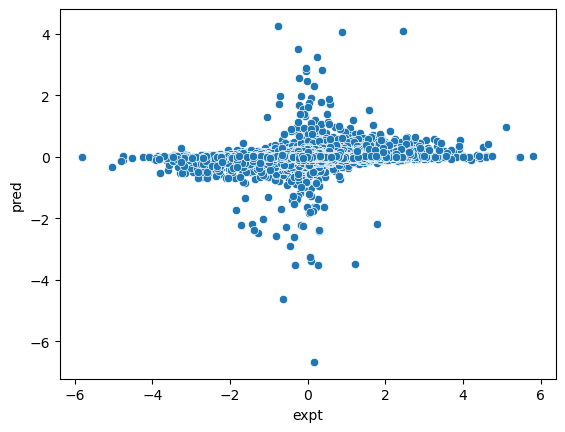

In [17]:
sns.scatterplot(data["expt"], data["pred"])

In [32]:
(np.sign(data["expt"])[np.abs(data["expt"]) >= 2] == np.sign(data["pred"])[np.abs(data["expt"]) >= 2]).mean()

0.6721479958890031

0        -1.130526
1         0.224948
2         0.618271
3         0.108427
4        -0.031179
            ...   
281322    0.028842
281323    0.310094
281324   -0.015574
281325   -1.216860
281326   -0.122321
Name: expt, Length: 252042, dtype: float64